# Automating

In [2]:
# load packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# sckit-learn packages
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

In [3]:
# load data
hotel_bookings = pd.read_csv('/Users/kiepeeh1/Documents/00 Working Projects/Hotel Data Analytics/Hotel Analytics/Data/Processed_Data/final_hotel_bookings.csv')

## Features Engineering

In [4]:
hotel_bookings['is_canceled'] = hotel_bookings['is_canceled'].astype('category') 
   
# convert all Dtype == 'object' columns to categorical type
for col in hotel_bookings.select_dtypes(include='object').columns:
    hotel_bookings[col] = hotel_bookings[col].astype('category')

In [5]:
# split the data into features and target variable
feature_cols = [
    'lead_time', 'market_segment', 'distribution_channel', 'customer_type',
    'stays_in_week_nights', 'stays_in_weekend_nights', 'adr', 'hotel',
    'deposit_type', 'arrival_date_month', 'arrival_date_week_number'
]
# ensure this only apply to categorical columns
#X = pd.get_dummies(hotel_bookings[feature_cols], drop_first=False)
num_cols = ['lead_time', 'stays_in_week_nights', 'stays_in_weekend_nights', 'adr', 'arrival_date_week_number']
cat_cols = [c for c in feature_cols if c not in num_cols]

X = hotel_bookings[feature_cols]
y = hotel_bookings['is_canceled']


## Model Training

In [6]:
# split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=19)
print(f"Training set size: {round(len(X_train)/len(X)*100)}% \n\
Testing set size: {round(len(X_test)/len(X)*100)}%")

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

Training set size: 70% 
Testing set size: 30%


### Building Models

In [7]:
from sklearn.calibration import CalibratedClassifierCV
import time
start_time = time.time()

logistic_reg = LogisticRegression(max_iter=5000)
# create pipelines for logistic regression and SVM (SVM with probability=True for predict_proba)
logistic_reg = Pipeline([
    ('preprocess', preprocessor),
    ('model', logistic_reg)
])

svm = CalibratedClassifierCV(SVC(), ensemble=False, method='sigmoid', cv=3)
svm = Pipeline([
    ('preprocess', preprocessor),
    ('model', svm)
])

#decision_tree = DecisionTreeClassifier()

# Training models
logistic_reg.fit(X_train, y_train)
svm.fit(X_train, y_train)
#decision_tree.fit(X_train, y_train)

# Precdictions
logistic_reg_pred = logistic_reg.predict(X_test)
svm_pred = svm.predict(X_test)
#decision_tree_pred = decision_tree.predict(X_test)


# Calculate runtime for each model
logistic_reg_runtime = time.time() - start_time
svm_runtime = time.time() - start_time
decision_tree_runtime = time.time() - start_time

# Print runtime results
print(f"Logistic Regression: {logistic_reg_runtime:.2f} seconds")
print(f"Support Vector Machine: {svm_runtime:.2f} seconds")
print(f"Decision Tree: {decision_tree_runtime:.2f} seconds")

/Users/kiepeeh1/Library/Python/3.9/lib/python/site-packages/sklearn/calibration.py:849: RuntimeWarning: divide by zero encountered in matmul
  grad = np.asarray([-g @ F, -g.sum()], dtype=np.float64)
/Users/kiepeeh1/Library/Python/3.9/lib/python/site-packages/sklearn/calibration.py:849: RuntimeWarning: overflow encountered in matmul
  grad = np.asarray([-g @ F, -g.sum()], dtype=np.float64)
/Users/kiepeeh1/Library/Python/3.9/lib/python/site-packages/sklearn/calibration.py:849: RuntimeWarning: invalid value encountered in matmul
  grad = np.asarray([-g @ F, -g.sum()], dtype=np.float64)


Logistic Regression: 222.94 seconds
Support Vector Machine: 222.94 seconds
Decision Tree: 222.94 seconds


### Model Evaluation

In [8]:
model_preds = {
    "Logistic Regression": logistic_reg_pred,
    "Support Vector Machine": svm_pred,
    #"Decision Tree": decision_tree_pred
}

for model, preds in model_preds.items():
    print(f"{model} Results:\n{classification_report(y_test, preds)}\n")

Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.76      0.96      0.85     19011
           1       0.64      0.18      0.28      7208

    accuracy                           0.75     26219
   macro avg       0.70      0.57      0.56     26219
weighted avg       0.72      0.75      0.69     26219


Support Vector Machine Results:
              precision    recall  f1-score   support

           0       0.76      0.97      0.85     19011
           1       0.68      0.17      0.28      7208

    accuracy                           0.75     26219
   macro avg       0.72      0.57      0.56     26219
weighted avg       0.74      0.75      0.69     26219




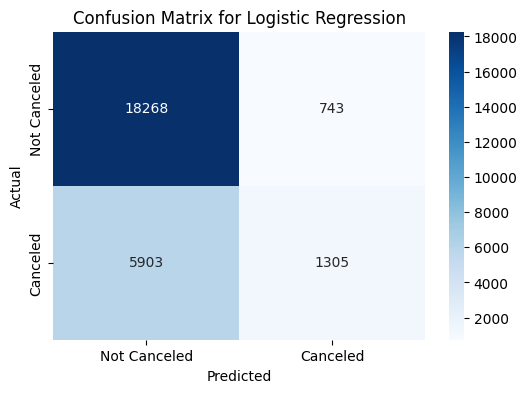

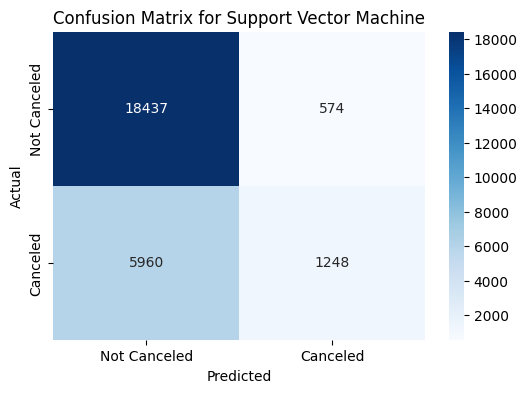

In [9]:
# Confusion Matrix for each model
for model, preds in model_preds.items():
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Canceled', 'Canceled'], yticklabels=['Not Canceled', 'Canceled'])
    plt.title(f'Confusion Matrix for {model}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

## Analyzing Results

In [14]:
# Logistic regression probabilities + prediction df
logreg_proba = pd.DataFrame(
    logistic_reg.predict_proba(X_test),
    columns=['logreg_pred_0', 'logreg_pred_1'],
    index=X_test.index
)
prediction_logreg = X_test.copy()
prediction_logreg['actual'] = y_test
prediction_logreg['predicted'] = logistic_reg_pred
prediction_logreg = prediction_logreg.join(logreg_proba)

# Decision tree probabilities + prediction df
#dt_proba = pd.DataFrame(
    #decision_tree.predict_proba(X_test),
    #columns=['dt_pred_0', 'dt_pred_1'],
    #index=X_test.index
#)
#prediction_dt = X_test.copy()
#prediction_dt['actual'] = y_test
#prediction_dt['predicted'] = decision_tree_pred
#prediction_dt = prediction_dt.join(dt_proba)

# SVM: ensure it supports predict_proba (re-fit with probability=True if necessary), then build df
#if not hasattr(svm, "predict_proba"):
    #svm = SVC(probability=True)
    #svm.fit(X_train, y_train)
    #svm_pred = svm.predict(X_test)

svm_proba = pd.DataFrame(
    svm.predict_proba(X_test),
    columns=['svm_pred_0', 'svm_pred_1'],
    index=X_test.index
)
prediction_svm = X_test.copy()
prediction_svm['actual'] = y_test
prediction_svm['predicted'] = svm_pred
prediction_svm = prediction_svm.join(svm_proba)

# merge the prediction dataframes for comparison
predictions_combined = prediction_logreg.merge(
    prediction_svm[['svm_pred_0', 'svm_pred_1', 'predicted']],
    left_index=True, right_index=True, suffixes=('_logreg', '_svm')
)

In [15]:
predictions_combined.head(10)

,lead_time,market_segment,distribution_channel,customer_type,stays_in_week_nights,stays_in_weekend_nights,adr,hotel,deposit_type,arrival_date_month,arrival_date_week_number,actual,predicted_logreg,logreg_pred_0,logreg_pred_1,svm_pred_0,svm_pred_1,predicted_svm
80726,1,Offline TA/TO,Corporate,Transient,1,0,110.50,City Hotel,No Deposit,May,19,0,0,0.926127,0.073873,0.769580,0.230420,0
79399,143,Offline TA/TO,TA/TO,Transient,1,1,89.10,City Hotel,No Deposit,April,15,0,0,0.798420,0.201580,0.777772,0.222228,0
36414,204,Offline TA/TO,TA/TO,Transient-Party,2,2,72.75,City Hotel,No Deposit,October,41,0,0,0.885735,0.114265,0.774166,0.225834,0
76834,2,Direct,Direct,Transient,1,0,143.00,City Hotel,No Deposit,March,9,0,0,0.863735,0.136265,0.771021,0.228979,0
79613,54,Direct,Direct,Transient,4,2,111.00,City Hotel,No Deposit,April,15,0,0,0.802938,0.197062,0.777900,0.222100,0
59730,33,Online TA,TA/TO,Transient,2,2,154.80,City Hotel,No Deposit,March,13,0,0,0.627700,0.372300,0.756425,0.243575,0
56790,150,Online TA,TA/TO,Transient-Party,3,1,89.67,City Hotel,No Deposit,March,13,1,0,0.734152,0.265848,0.814283,0.185717,0
74183,105,Online TA,TA/TO,Transient,1,1,95.37,City Hotel,No Deposit,December,53,0,0,0.587553,0.412447,0.621764,0.378236,0
59865,56,Offline TA/TO,TA/TO,Transient,3,1,103.28,City Hotel,No Deposit,March,14,0,0,0.848836,0.151164,0.772288,0.227712,0
55709,5,Corporate,Corporate,Transient,1,0,74.00,City Hotel,No Deposit,December,49,0,0,0.845642,0.154358,0.771128,0.228872,0


In [12]:
prediction_logreg.head(10)

,lead_time,market_segment,distribution_channel,customer_type,stays_in_week_nights,stays_in_weekend_nights,adr,hotel,deposit_type,arrival_date_month,arrival_date_week_number,actual,predicted,logreg_pred_0,logreg_pred_1
80726,1,Offline TA/TO,Corporate,Transient,1,0,110.50,City Hotel,No Deposit,May,19,0,0,0.926127,0.073873
79399,143,Offline TA/TO,TA/TO,Transient,1,1,89.10,City Hotel,No Deposit,April,15,0,0,0.798420,0.201580
36414,204,Offline TA/TO,TA/TO,Transient-Party,2,2,72.75,City Hotel,No Deposit,October,41,0,0,0.885735,0.114265
76834,2,Direct,Direct,Transient,1,0,143.00,City Hotel,No Deposit,March,9,0,0,0.863735,0.136265
79613,54,Direct,Direct,Transient,4,2,111.00,City Hotel,No Deposit,April,15,0,0,0.802938,0.197062
59730,33,Online TA,TA/TO,Transient,2,2,154.80,City Hotel,No Deposit,March,13,0,0,0.627700,0.372300
56790,150,Online TA,TA/TO,Transient-Party,3,1,89.67,City Hotel,No Deposit,March,13,1,0,0.734152,0.265848
74183,105,Online TA,TA/TO,Transient,1,1,95.37,City Hotel,No Deposit,December,53,0,0,0.587553,0.412447
59865,56,Offline TA/TO,TA/TO,Transient,3,1,103.28,City Hotel,No Deposit,March,14,0,0,0.848836,0.151164
55709,5,Corporate,Corporate,Transient,1,0,74.00,City Hotel,No Deposit,December,49,0,0,0.845642,0.154358


In [13]:
prediction_svm.head(10)

,lead_time,market_segment,distribution_channel,customer_type,stays_in_week_nights,stays_in_weekend_nights,adr,hotel,deposit_type,arrival_date_month,arrival_date_week_number,actual,predicted,svm_pred_0,svm_pred_1
80726,1,Offline TA/TO,Corporate,Transient,1,0,110.50,City Hotel,No Deposit,May,19,0,0,0.769580,0.230420
79399,143,Offline TA/TO,TA/TO,Transient,1,1,89.10,City Hotel,No Deposit,April,15,0,0,0.777772,0.222228
36414,204,Offline TA/TO,TA/TO,Transient-Party,2,2,72.75,City Hotel,No Deposit,October,41,0,0,0.774166,0.225834
76834,2,Direct,Direct,Transient,1,0,143.00,City Hotel,No Deposit,March,9,0,0,0.771021,0.228979
79613,54,Direct,Direct,Transient,4,2,111.00,City Hotel,No Deposit,April,15,0,0,0.777900,0.222100
59730,33,Online TA,TA/TO,Transient,2,2,154.80,City Hotel,No Deposit,March,13,0,0,0.756425,0.243575
56790,150,Online TA,TA/TO,Transient-Party,3,1,89.67,City Hotel,No Deposit,March,13,1,0,0.814283,0.185717
74183,105,Online TA,TA/TO,Transient,1,1,95.37,City Hotel,No Deposit,December,53,0,0,0.621764,0.378236
59865,56,Offline TA/TO,TA/TO,Transient,3,1,103.28,City Hotel,No Deposit,March,14,0,0,0.772288,0.227712
55709,5,Corporate,Corporate,Transient,1,0,74.00,City Hotel,No Deposit,December,49,0,0,0.771128,0.228872


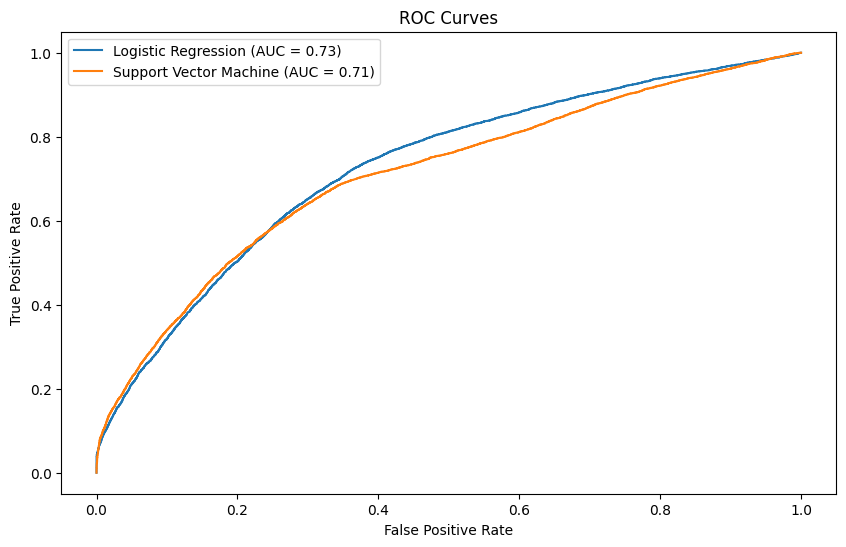

In [16]:
# plot ROC curves for each model
plt.figure(figsize=(10, 6))
for model, preds in model_preds.items():
    if model == "Logistic Regression":
        y_proba = logistic_reg.predict_proba(X_test)[:, 1]
    elif model == "Support Vector Machine":
        y_proba = svm.predict_proba(X_test)[:, 1]
    #elif model == "Decision Tree":
        #y_proba = decision_tree.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{model} (AUC = {auc_score:.2f})')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()

In [18]:
# Plot importance of features for Logistic Regression
features_importance_df = pd.DataFrame({
    'feature': X_test.columns,
    'coefficient': logistic_reg.coef_[0]
})
features_importance_df = features_importance_df.sort_values('coefficient', ascending=False)
features_importance_df.head(10)

#feature_importance = pd.DataFrame({
    #'Feature': X.columns,
    #'Importance': logistic_reg.named_steps['model'].coef_[0]
#}).sort_values(by='Importance', ascending=False)
#feature_importance.head(10)

AttributeError: 'Pipeline' object has no attribute 'coef_'